In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree


In [21]:
titanic = pd.read_csv('titanic_train.csv')
titanic.info()
titanic.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
features = ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked']
target = ['Survived']

In [11]:
num_imp = SimpleImputer(strategy='median')
titanic[['Age']] = num_imp.fit_transform(titanic[['Age']])
cat_imp = SimpleImputer(strategy='most_frequent')
titanic[['Embarked']] = cat_imp.fit_transform(titanic[['Embarked']])

In [15]:
le = LabelEncoder()
titanic['Sex'] = le.fit_transform(titanic['Sex'])
titanic['Embarked'] = le.fit_transform(titanic['Embarked'])

In [19]:
X = titanic[features]
y = titanic[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [42]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

acc = model.score(X_test, y_test)
print(f' acc {acc}')

 acc 0.776536312849162


In [39]:
#pre pruning
max_depth = [3,5,7,8,9,10,11,12,13,15,17]

for depth in max_depth:
    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = model.score(X_test, y_test)
    print(f'for depth {depth} acc {acc}')

for depth 3 acc 0.7988826815642458
for depth 5 acc 0.7988826815642458
for depth 7 acc 0.7988826815642458
for depth 8 acc 0.7932960893854749
for depth 9 acc 0.7877094972067039
for depth 10 acc 0.7877094972067039
for depth 11 acc 0.8044692737430168
for depth 12 acc 0.7877094972067039
for depth 13 acc 0.7821229050279329
for depth 15 acc 0.7541899441340782
for depth 17 acc 0.7541899441340782


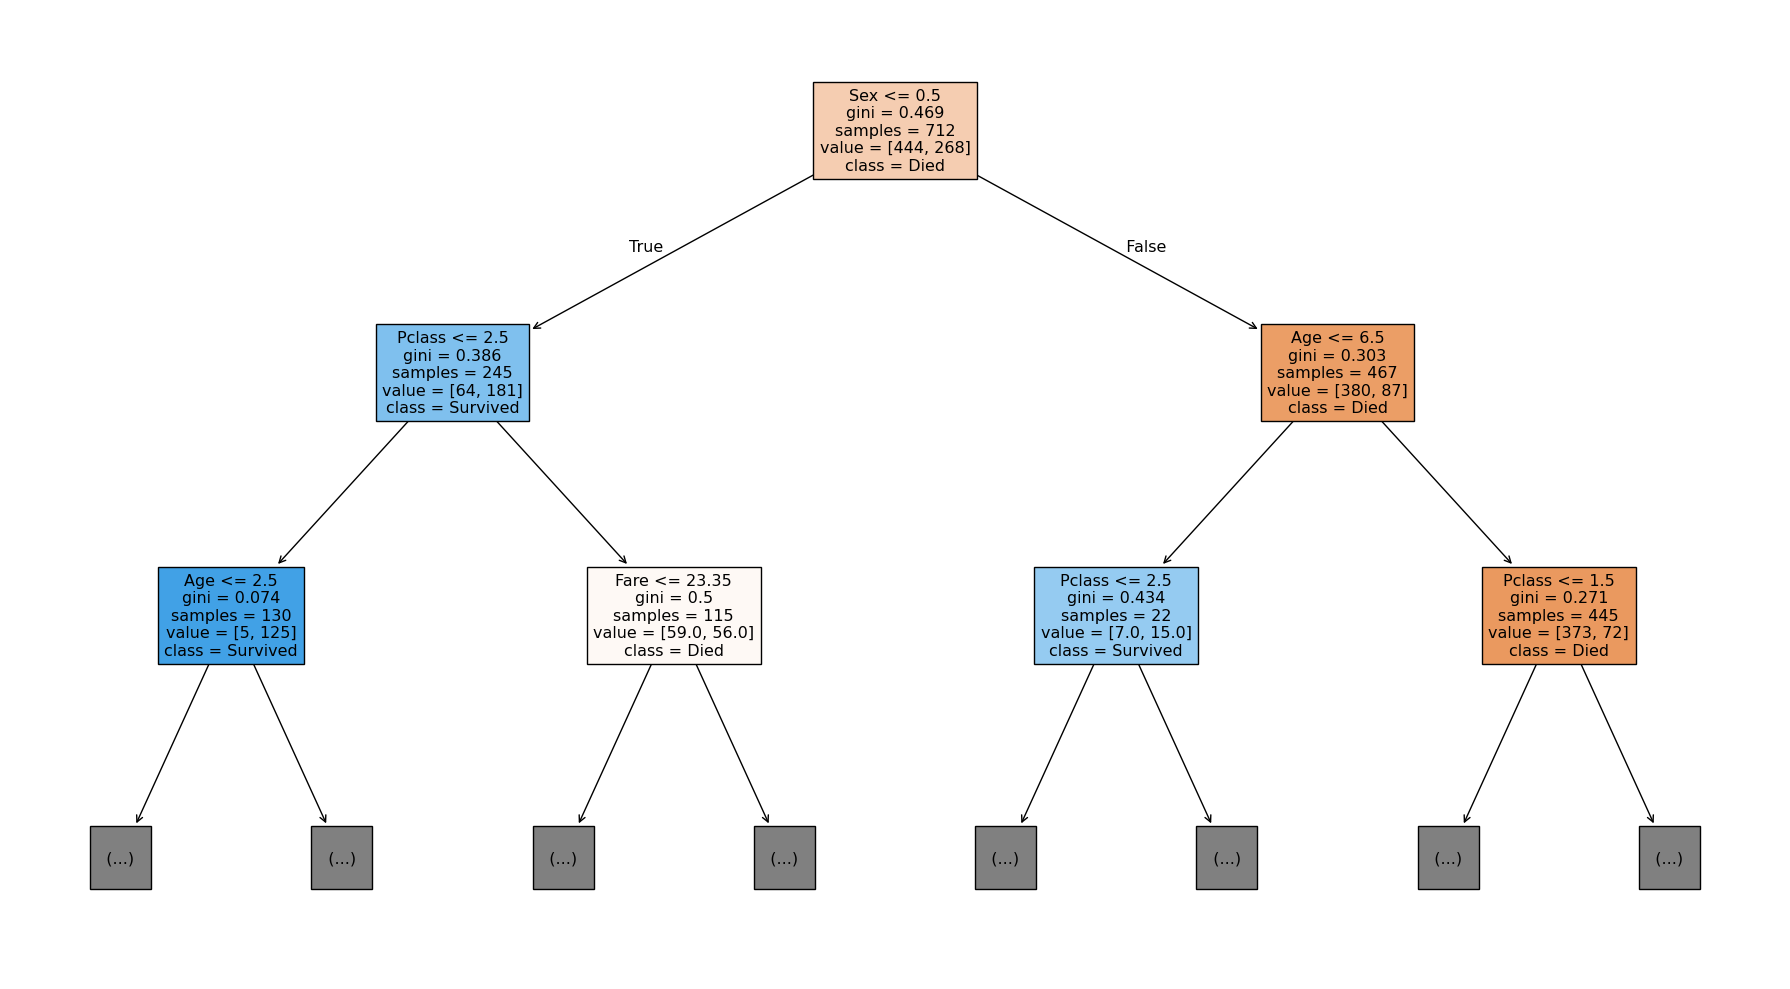

In [35]:
plt.figure(figsize=(18, 10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Died', 'Survived'],
    filled=True,
    max_depth=2
    
)
plt.tight_layout()
plt.show()

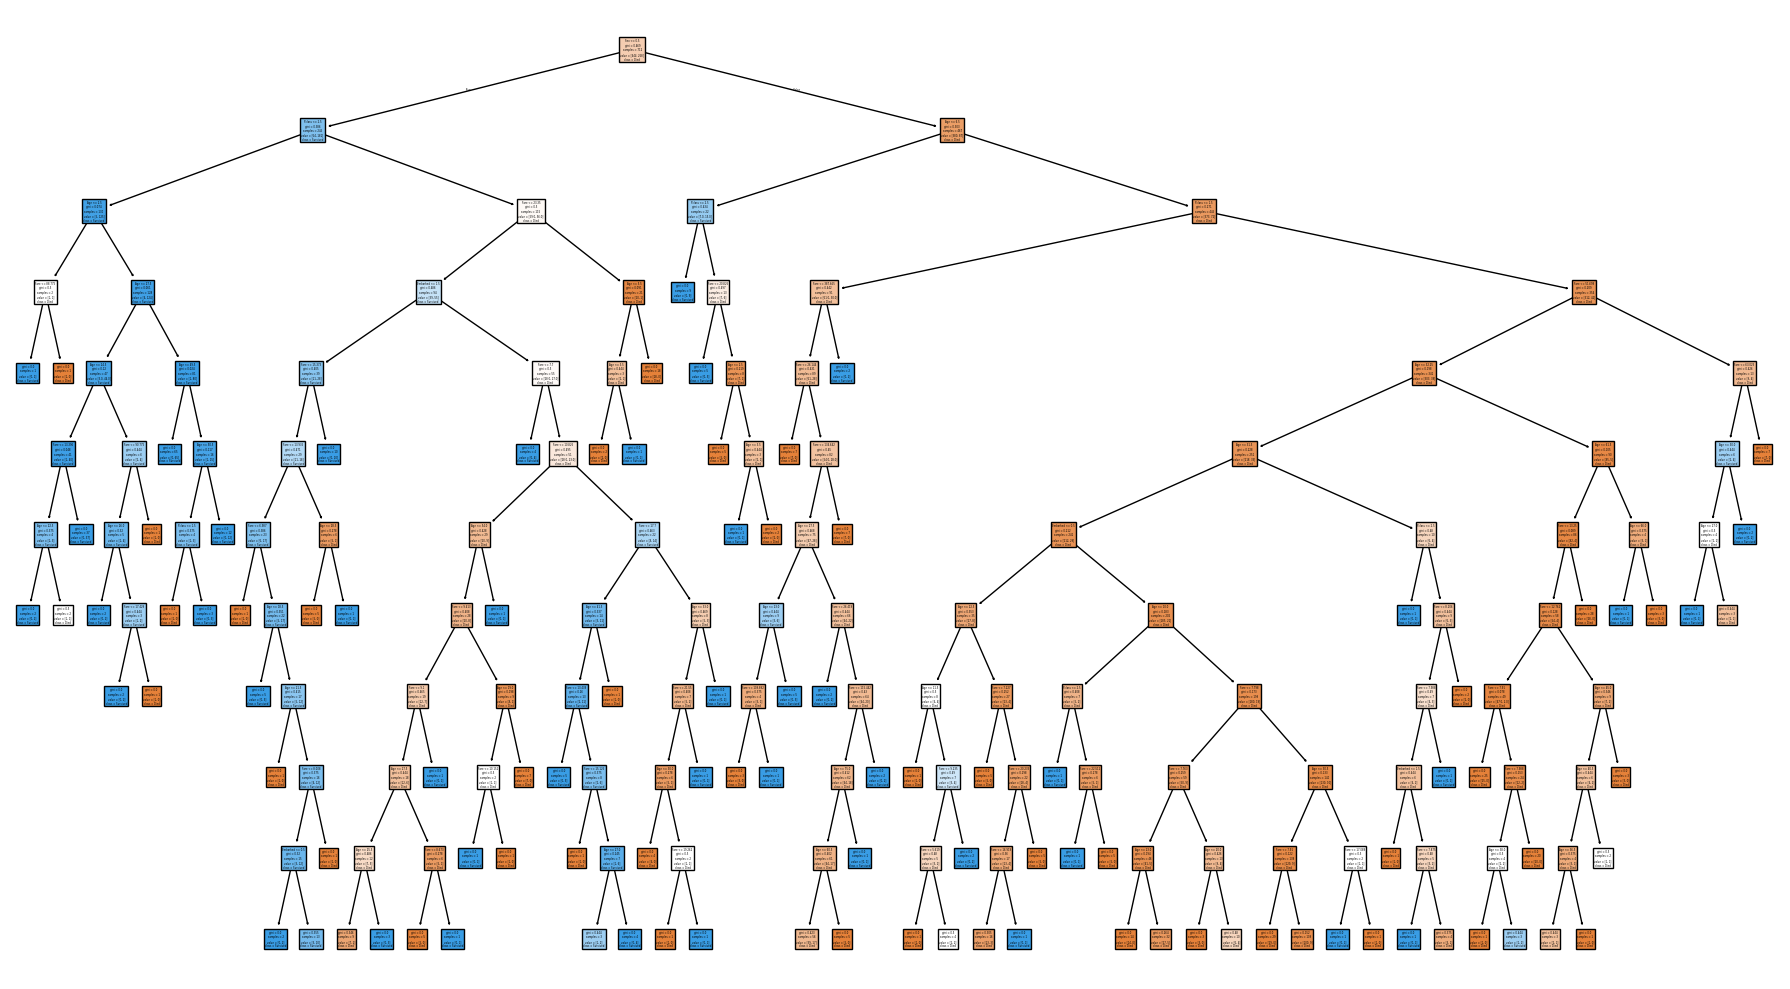

In [37]:
#pre pruning
max_depth = [3,5,7,9,11,13,15,17]

for depth in max_depth:
    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = model.score(X_test, y_test)
    # print(f'for depth {depth} acc {acc}')

    if depth == 11:
        plt.figure(figsize=(18, 10))
        plot_tree(
            model,
            feature_names=X.columns,
            class_names=['Died', 'Survived'],
            filled=True
        )
        plt.tight_layout()
        plt.show()

for split 5 acc 0.8156424581005587
for split 10 acc 0.8379888268156425


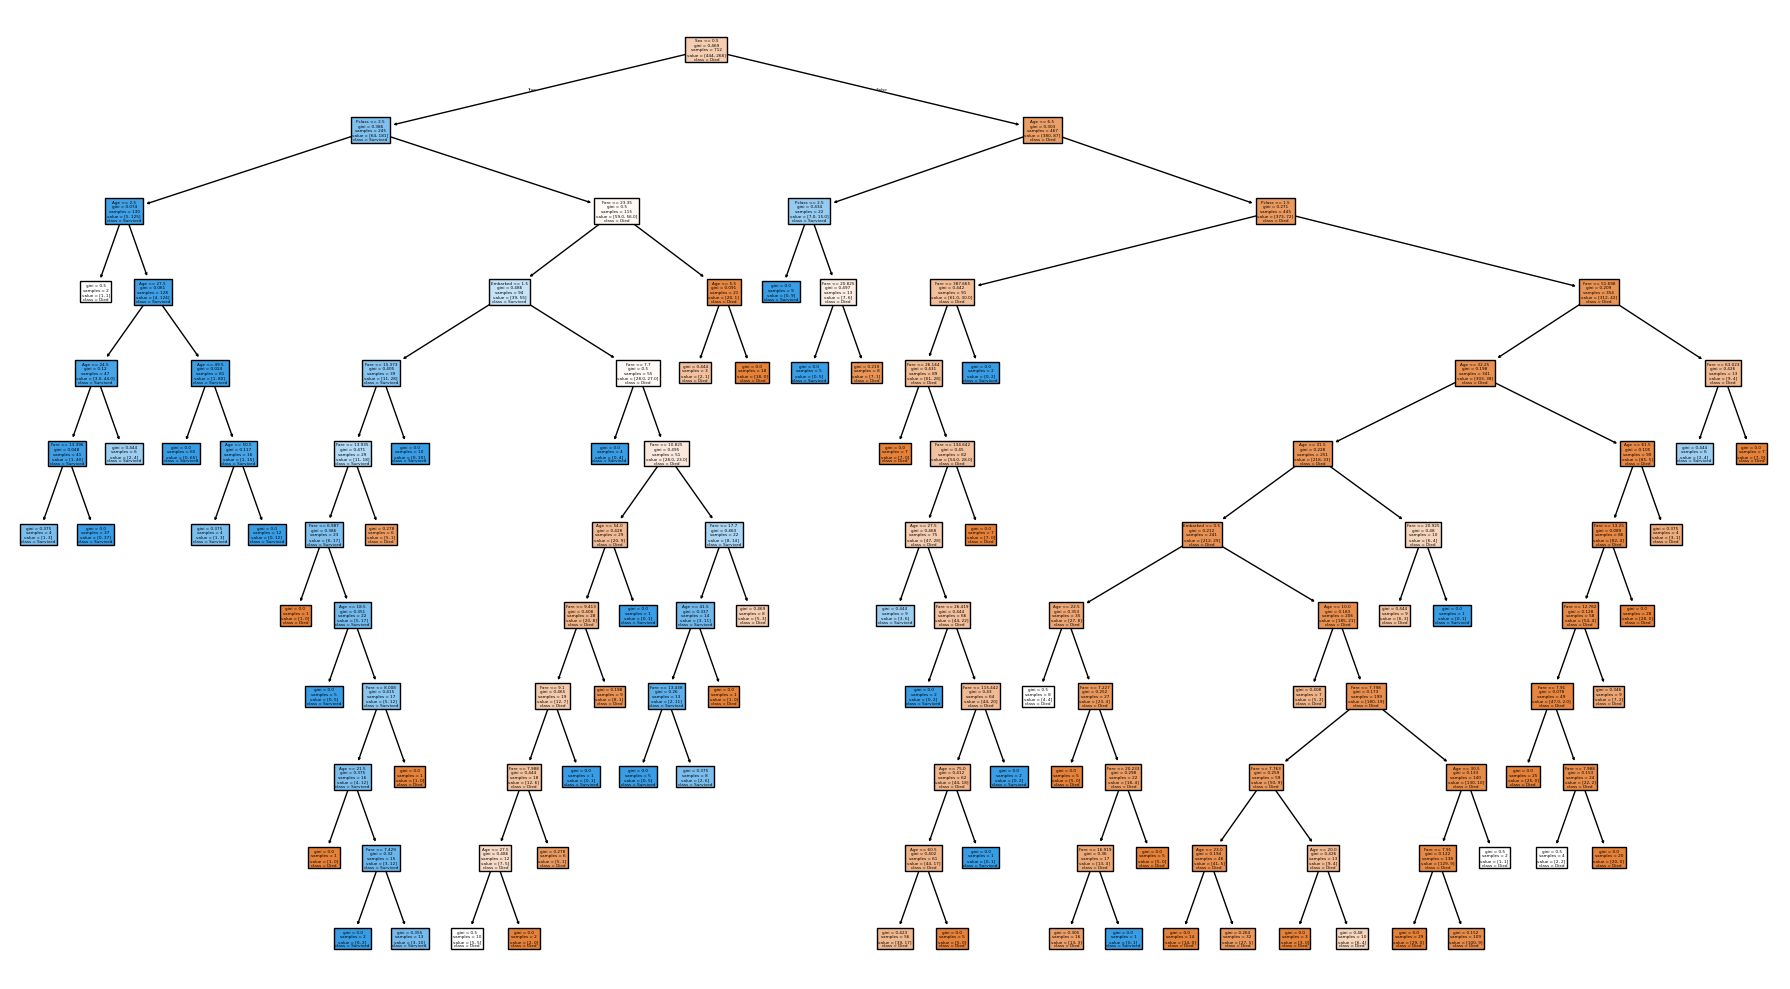

for split 15 acc 0.8324022346368715
for split 20 acc 0.8379888268156425
for split 25 acc 0.8212290502793296
for split 30 acc 0.8100558659217877
for split 35 acc 0.8100558659217877
for split 40 acc 0.8100558659217877


In [64]:
min_samples_splits = [5, 10, 15, 20, 25, 30, 35, 40]
for splits in min_sample_splits:
    model = DecisionTreeClassifier(max_depth=11, min_samples_split=splits)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = model.score(X_test, y_test)
    print(f'for split {splits} acc {acc}')

    if splits==10:
        plt.figure(figsize=(18, 10))
        plot_tree(
            model,
            feature_names=X.columns,
            class_names=['Died', 'Survived'],
            filled=True
        )
        plt.tight_layout()
        plt.show()

In [56]:
#post pruning

full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train, y_train)

path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
print(ccp_alphas)

[0.00000000e+00 0.00000000e+00 6.68806849e-05 1.45921494e-04
 1.84428555e-04 2.00642055e-04 2.34082397e-04 2.34082397e-04
 3.51123596e-04 4.68164794e-04 4.68164794e-04 5.61797753e-04
 6.24219725e-04 6.67991230e-04 7.02247191e-04 7.02247191e-04
 8.19288390e-04 8.19288390e-04 8.32292967e-04 8.42696629e-04
 8.42696629e-04 8.42696629e-04 8.94231048e-04 8.99610781e-04
 9.24769963e-04 9.36329588e-04 9.36329588e-04 9.36329588e-04
 9.88347898e-04 1.00253471e-03 1.05337079e-03 1.07400895e-03
 1.08038029e-03 1.11865144e-03 1.12359551e-03 1.12359551e-03
 1.13139825e-03 1.17041199e-03 1.18841832e-03 1.22566125e-03
 1.22893258e-03 1.22893258e-03 1.24361593e-03 1.24843945e-03
 1.27565833e-03 1.30996111e-03 1.33761370e-03 1.37044603e-03
 1.46301498e-03 1.47927070e-03 1.51142557e-03 1.54072312e-03
 1.56675436e-03 1.60434338e-03 1.66892062e-03 1.76144762e-03
 1.86751451e-03 2.10674157e-03 2.34082397e-03 2.41226470e-03
 2.64273538e-03 2.69412911e-03 3.43770913e-03 3.56327570e-03
 5.47433606e-03 9.055400

In [69]:
trees = []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    model.fit(X_train, y_train)

    acc = model.score(X_test, y_test)
    trees.append((model, alpha))
    

In [70]:
best_acc = 0
best_alpha = 0

for model, alpha in trees:
    cur_acc = model.score(X_test, y_test)
    if cur_acc > best_acc:
        best_acc = cur_acc
        best_alpha = alpha

In [71]:
print(best_alpha)
print(best_acc)

0.0015407231242023183
0.8379888268156425


In [101]:
best_model = DecisionTreeClassifier(ccp_alpha=best_alpha)
best_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


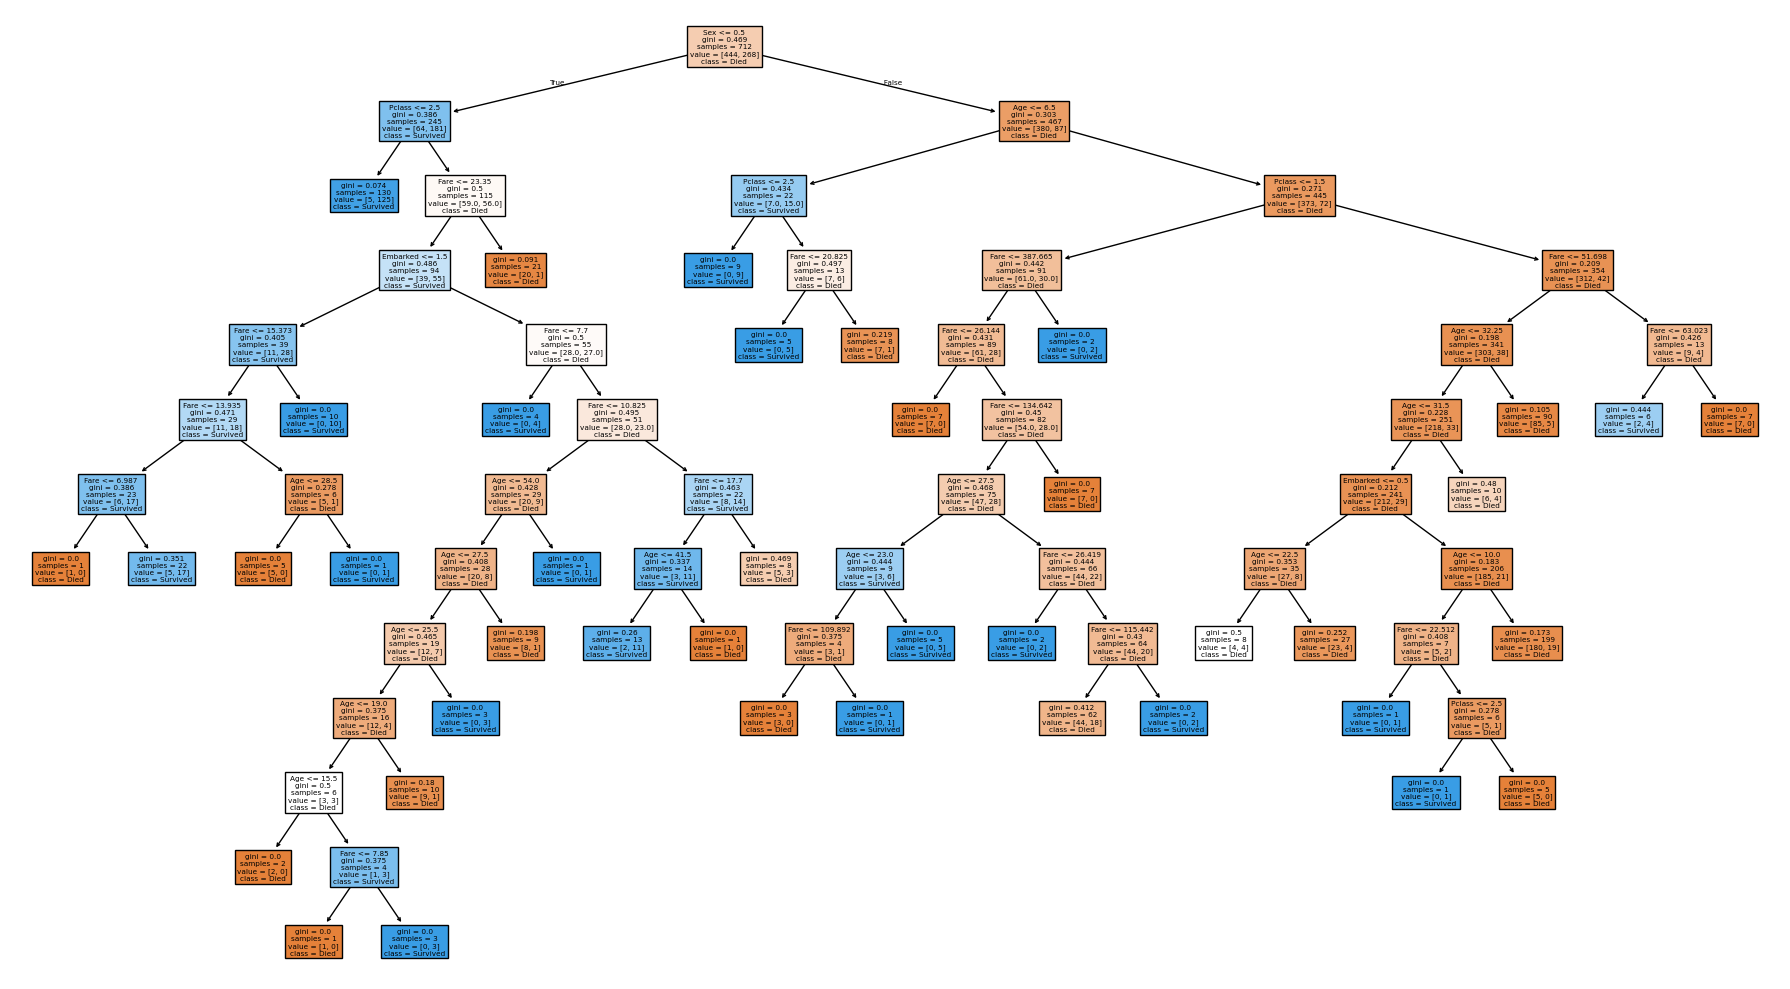

In [102]:
plt.figure(figsize=(18, 10))
plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=['Died', 'Survived'],
    filled=True
)
plt.tight_layout()
plt.show()

In [103]:
print(best_model.score(X_test, y_test))

0.8435754189944135
